In [ ]:
import pandas as pd
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import geodatasets
from shapely.geometry import Point
import seaborn as sns

In [3]:
# Helper functions.
# Convert the column names into same format.
def standardize_name(name):
    if pd.isna(name):
        return name
    return str(name).strip().lower().replace(" ", "_") 

# Convert the data in to uppercase.
def to_uppercase(x):
    if pd.isna(x):
        return x
    return str(x).upper()


In [ ]:
# Load the datasets and check for NaN values.
df_vio = pd.read_csv("Violence_Reduction_-_Victims_of_Homicides_and_Non-Fatal_Shootings_20260302.csv")
df_stat = pd.read_csv("Public_Health_Statistics_-_Selected_public_health_indicators_by_Chicago_community_area_-_Historical_20260302.csv")

# Check if there is any data that doesn't have a value.
df_vio["COMMUNITY_AREA"].isna().sum()
df_stat["Community Area Name"].isna().sum()

# Drop rows where "COMMUNITY_AREA" column has nan vaule.
df_vio = df_vio.dropna(subset=["COMMUNITY_AREA"])

# Step 1: Ensure the column namse and the combine keys are having the same format.
df_vio.columns = [standardize_name(col) for col in df_vio.columns]
df_stat.columns = [standardize_name(col) for col in df_stat.columns]

# Step 2: Ensure the combine keys are having the same format.
# Check the information within the keys.
df_vio["community_area"].unique()
df_stat["community_area_name"].unique()

# Mapping for known mismatches, like O'Hare.
name_mapping = {"OHARE": "O'HARE", "Montclaire": "Montclare"}
df_vio["community_area"] = df_vio["community_area"].replace(name_mapping)
df_stat["community_area_name"] = df_stat["community_area_name"].replace(name_mapping)

df_vio["community_area"] = df_vio["community_area"].apply(to_uppercase)
df_stat["community_area_name"] = df_stat["community_area_name"].apply(to_uppercase)

# Step 3: Create crosswalk from number using df_stat as source of truth.
crosswalk = (df_stat[["community_area", "community_area_name"]].drop_duplicates()
             .set_index("community_area_name")["community_area"].to_dict())

# Step 4: Filter the df_stat with our desired year(2005-2010).
# Convert to datetime.
df_vio["date"] = pd.to_datetime(df_vio["date"], format="%m/%d/%Y %I:%M:%S %p")
df_vio["date_only"] = df_vio["date"].dt.date
df_vio["year"] = df_vio["date"].dt.year
#df_vio["time"] = df_vio["date"].dt.time


# Step 5: Combine the two datasets with keys.
df_merged = pd.merge(df_vio, df_stat, left_on="community_area", right_on="community_area_name")

# Step 6: Validate the join.
vio_area = df_vio["community_area"].unique()
stat_area = df_stat["community_area_name"].unique()
merged_area = df_merged["community_area_x"].unique()

# Convert arrays to sets.
vio_set = set(vio_area)
stat_set = set(stat_area)
merged_set = set(merged_area)

# Check differences.
print("In vio_area but not in stat_area:", vio_set - stat_set)
print("In stat_area but not in vio_area:", stat_set - vio_set)

print("In vio_area but not in merged_area:", vio_set - merged_set)
print("In merged_area but not in vio_area:", merged_set - vio_set)

print("In stat_area but not in merged_area:", stat_set - merged_set)
print("In merged_area but not in stat_area:", merged_set - stat_set)

# Step 8: Filter the time period where both datasets overlap (2005 to 2010).
df_merged = df_merged[(df_merged["year"] >= 2005) & (df_merged["year"] <= 2010)]

# Save the merged file if needed.
df_merged.to_csv("merged.csv")


# Output the results.
#df_vio["community_area"].head(5)
#df_vio["community_area"].value_counts()
#f_vio.shape
#df_vio.dtypes
#df_stat["community_area_name"].head(5)
#df_stat["community_area_name"].value_counts()
#df_stat.dtypes
#df_merged.head(5)
#df_merged.head(5)


In vio_area but not in stat_area: set()
In stat_area but not in vio_area: set()
In vio_area but not in merged_area: set()
In merged_area but not in vio_area: set()
In stat_area but not in merged_area: set()
In merged_area but not in stat_area: set()


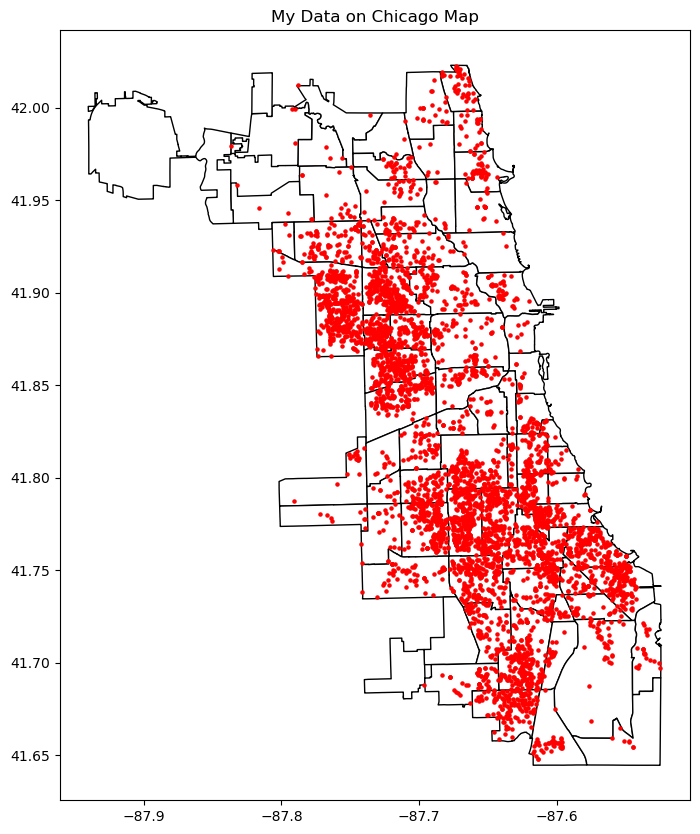

In [51]:
# Method comes from: https://towardsdatascience.com/plotting-maps-with-geopandas-428c97295a73/
# Chicago polygons.
chicago = gpd.read_file(geodatasets.get_path("geoda.chicago_commpop"))

df_merged = df_merged[(df_merged["year"] >= 2005) & (df_merged["year"] <= 2010)]

# Convert data to a GeoDataFrame.
geometry = [Point(xy) for xy in zip(df_merged["longitude"], df_merged["latitude"])]
geo_df = gpd.GeoDataFrame(df_merged, geometry=geometry)
geo_df.set_crs(epsg=4326, inplace=True)
geo_df = geo_df.to_crs(chicago.crs)

fig, ax = plt.subplots(figsize=(10, 10))

# Base map.
chicago.plot(ax=ax, color="white", edgecolor="black")

# Data.
geo_df.plot(ax=ax, color="red", markersize=5)

plt.title("My Data on Chicago Map")
plt.show()

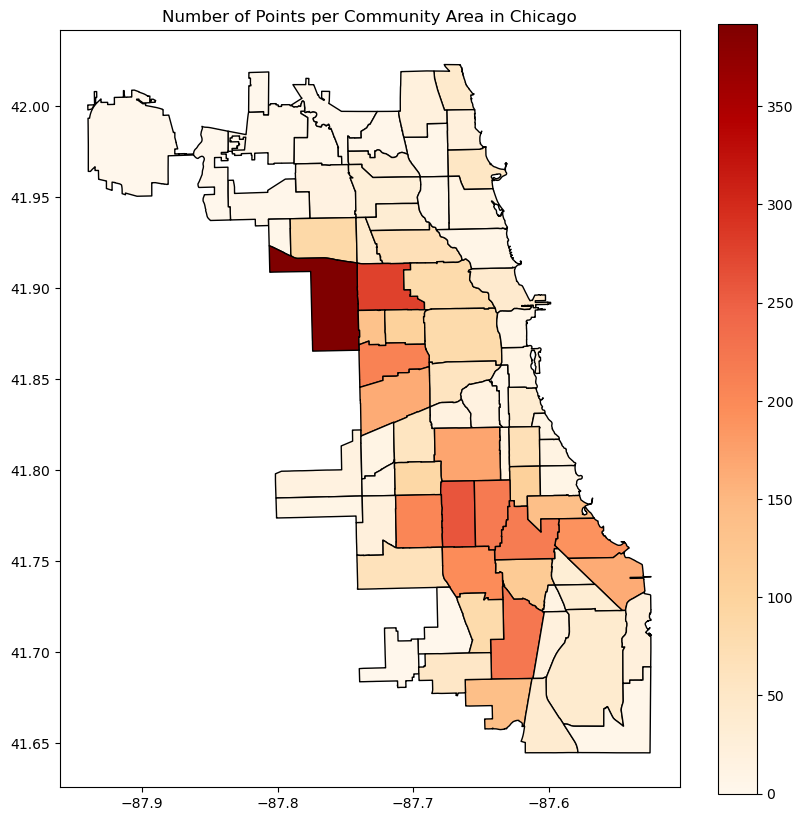

In [52]:
# Assign each point to a community area.
joined = gpd.sjoin(geo_df, chicago, how="left", predicate='within')

# Count points per community area.
counts = joined.groupby("community")[['geometry']].count().rename(columns={'geometry': 'point_count'})

# Merge counts back to chicago polygons.
chicago_counts = chicago.merge(counts, left_on="community", right_index=True, how="left")
chicago_counts['point_count'] = chicago_counts['point_count'].fillna(0)  # fill NaN with 0

# Plot choropleth.
fig, ax = plt.subplots(figsize=(10, 10))
chicago_counts.plot(column='point_count', ax=ax, cmap='OrRd', edgecolor='black', legend=True)
plt.title("Number of Points per Community Area in Chicago")
plt.show()

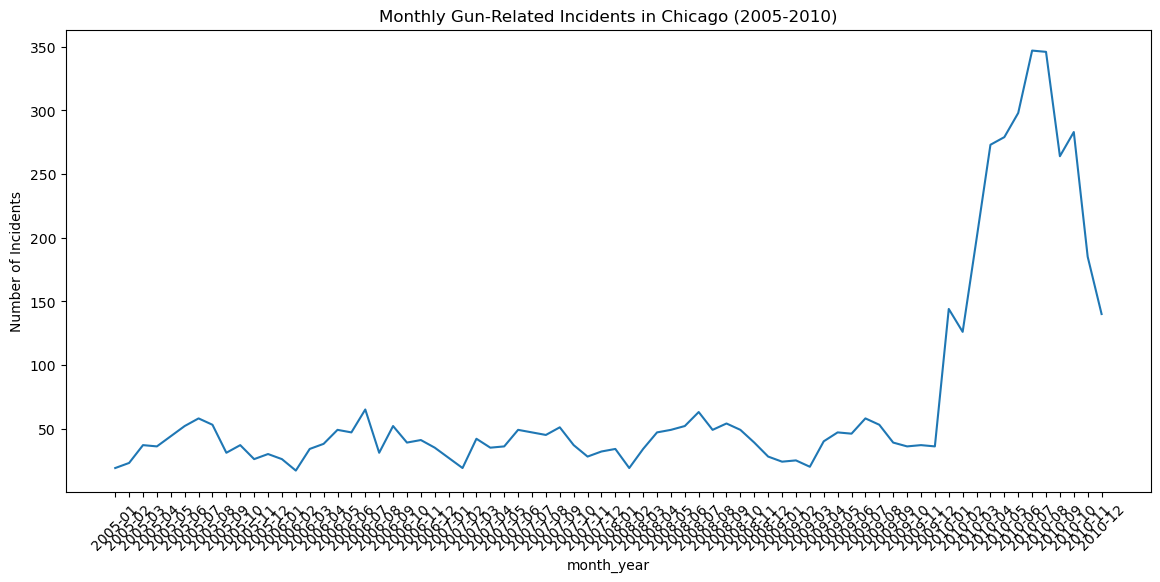

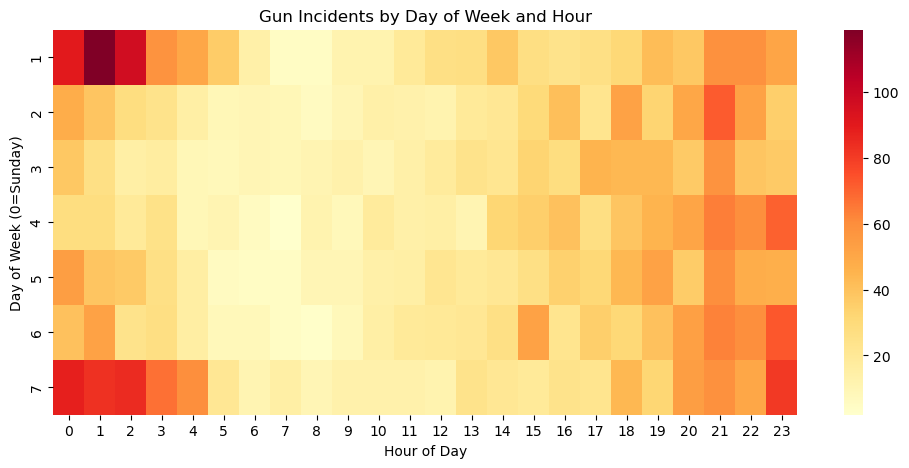

In [ ]:
# Gun violence incidents by year and month.
df_merged['month_year'] = df_merged['date'].dt.to_period('M')

monthly_trend = df_merged.groupby('month_year').size().reset_index(name='incidents')
monthly_trend['month_year'] = monthly_trend['month_year'].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_trend, x='month_year', y='incidents')
plt.xticks(rotation=45)
plt.title('Monthly Gun-Related Incidents in Chicago (2005-2010)')
plt.ylabel('Number of Incidents')
plt.show()

# By day of week and hour.
plt.figure(figsize=(12, 5))
sns.heatmap(df_merged.pivot_table(index='day_of_week', columns='hour', aggfunc='size', fill_value=0),
            cmap='YlOrRd', annot=False)
plt.title('Gun Incidents by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week (0=Sunday)')
plt.show()

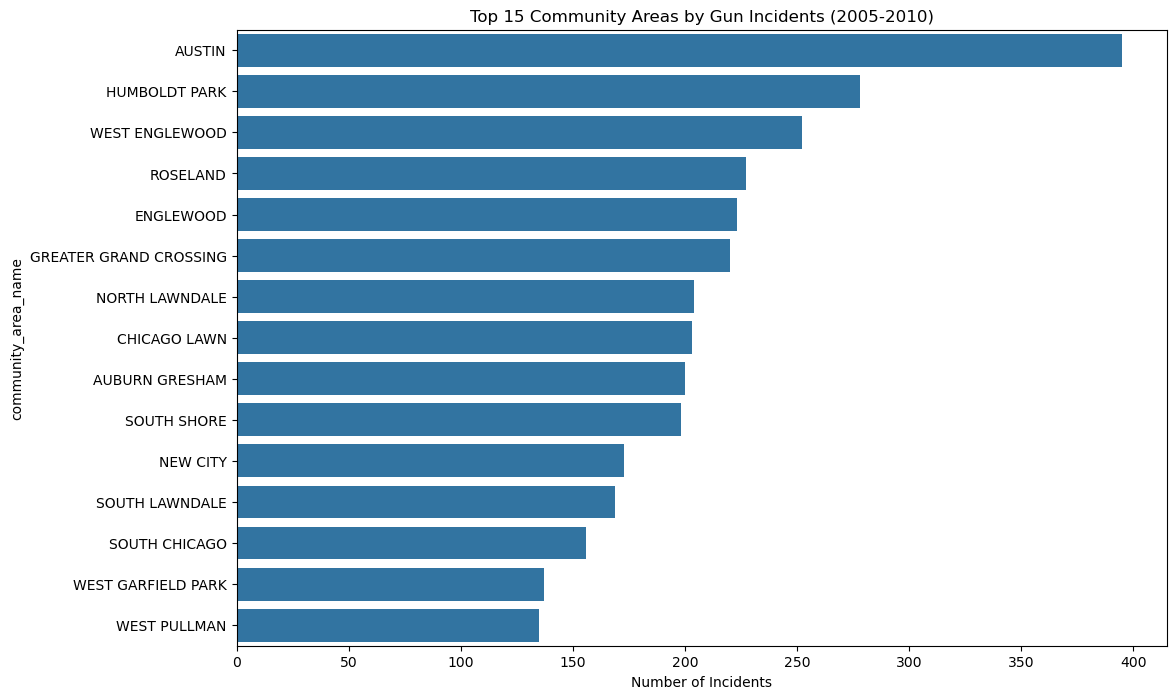

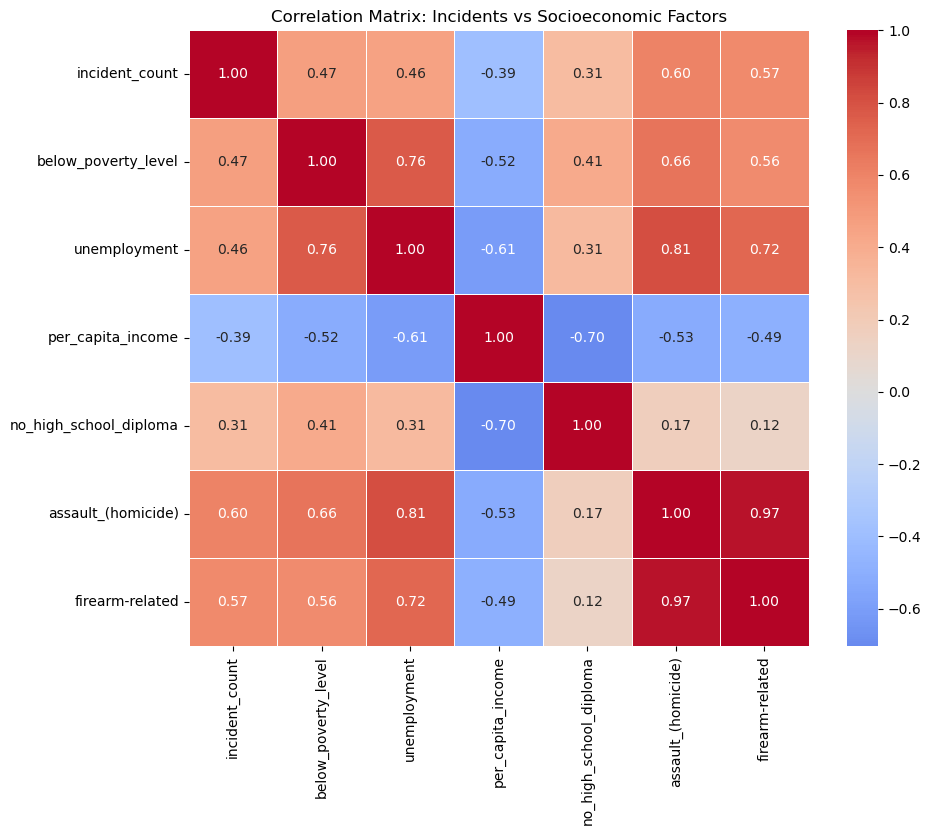

In [50]:
# Full corrected version
area_stats = (df_merged.groupby('community_area_name')
              .agg({
                  'unique_id': 'count',
                  'below_poverty_level': 'mean',
                  'unemployment': 'mean',
                  'per_capita_income': 'mean',
                  'no_high_school_diploma': 'mean',
                  'assault_(homicide)': 'mean',
                  'firearm-related': 'mean'
              })
              .rename(columns={'unique_id': 'incident_count'})
              .reset_index())

# Top 15 most dangerous areas
top15 = area_stats.nlargest(15, 'incident_count')

plt.figure(figsize=(12, 8))
sns.barplot(data=top15, y='community_area_name', x='incident_count')
plt.title('Top 15 Community Areas by Gun Incidents (2005-2010)')
plt.xlabel('Number of Incidents')
plt.show()

# Correlation heatmap
corr = area_stats[['incident_count'] + socio_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Incidents vs Socioeconomic Factors')
plt.show()

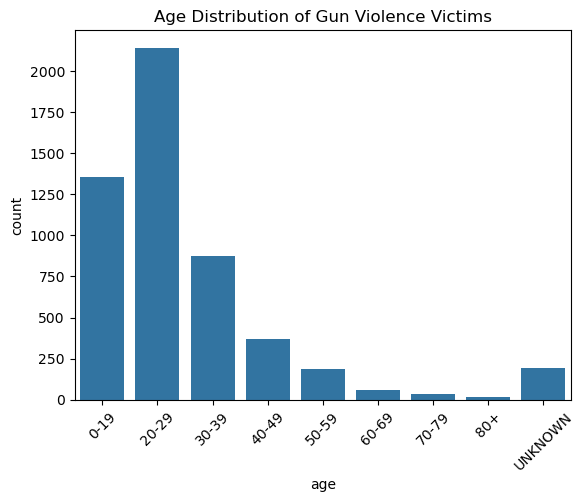

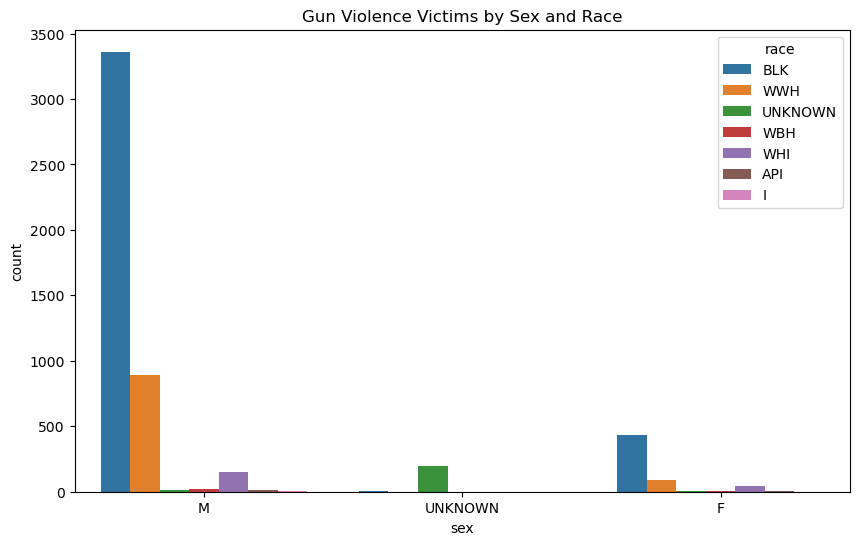

community_area_name
LINCOLN SQUARE     100.000000
BURNSIDE           100.000000
ARMOUR SQUARE      100.000000
FOREST GLEN        100.000000
JEFFERSON PARK     100.000000
O'HARE             100.000000
NORWOOD PARK       100.000000
MOUNT GREENWOOD    100.000000
BEVERLY            100.000000
ARCHER HEIGHTS      90.909091
dtype: float64


In [ ]:
# Age group distribution.
age_order = ['0-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+', 'UNKNOWN']
sns.countplot(data=df_merged, x='age', order=age_order)
plt.title('Age Distribution of Gun Violence Victims')
plt.xticks(rotation=45)
plt.show()

# By sex and race.
plt.figure(figsize=(10, 6))
sns.countplot(data=df_merged, x='sex', hue='race')
plt.title('Gun Violence Victims by Sex and Race')
plt.show()

# Homicide rate by community area.
homicides = df_merged[df_merged['victimization_primary'] == 'HOMICIDE']
homicide_rate = homicides.groupby('community_area_name').size() / \
                df_merged.groupby('community_area_name').size() * 100

print(homicide_rate.sort_values(ascending=False).head(10))

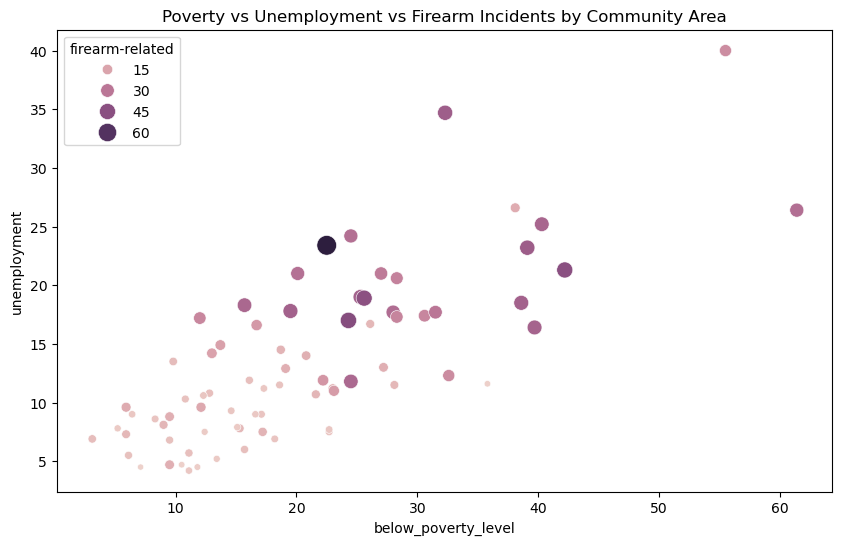

In [ ]:
# Relationship between poverty/unemployment and gun violence.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged.groupby('community_area_name').agg({
    'below_poverty_level': 'mean',
    'unemployment': 'mean',
    'firearm-related': 'mean'  # or use incident count
}).reset_index(), 
x='below_poverty_level', y='unemployment', 
size='firearm-related', hue='firearm-related',
sizes=(20, 200))
plt.title('Poverty vs Unemployment vs Firearm Incidents by Community Area')
plt.show()